# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Nur Rahmawati
- **Email:** nurrahmawati0217@gmail.com
- **ID Dicoding:** nur_rahmawati

## Menentukan Pertanyaan Bisnis

- Bagaimana perbedaan pola penyewaan sepeda antara hari kerja (workingday = 1) dan hari libur (workingday = 0) pada setiap jamnya?
- Pada jam berapa pengguna 'Casual' paling aktif melakukan penyewaan dibandingkan pengguna 'Registered'?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
import matplotlib.ticker as ticker

## Data Wrangling

### Gathering Data

In [19]:
df_day = pd.read_csv('day.csv')
df_hour = pd.read_csv('hour.csv')
print(df_hour.head())
print(df_day.head())

   instant      dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1   0        0        6           0   
1        2  2011-01-01       1   0     1   1        0        6           0   
2        3  2011-01-01       1   0     1   2        0        6           0   
3        4  2011-01-01       1   0     1   3        0        6           0   
4        5  2011-01-01       1   0     1   4        0        6           0   

   weathersit  temp   atemp   hum  windspeed  casual  registered  cnt  
0           1  0.24  0.2879  0.81        0.0       3          13   16  
1           1  0.22  0.2727  0.80        0.0       8          32   40  
2           1  0.22  0.2727  0.80        0.0       5          27   32  
3           1  0.24  0.2879  0.75        0.0       3          10   13  
4           1  0.24  0.2879  0.75        0.0       0           1    1  
   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01   

**Insight:**
- Data memuat informasi historis penyewaan sepeda per jam, mulai dari tanggal 1 Januari 2011 (berdasarkan baris awal).
- Struktur data awal terlihat rapi dengan kolom kunci seperti dteday (tanggal), hr (jam), dan cnt (total penyewaan)

### Assessing Data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB
None
instant       0
dteday        0
season      

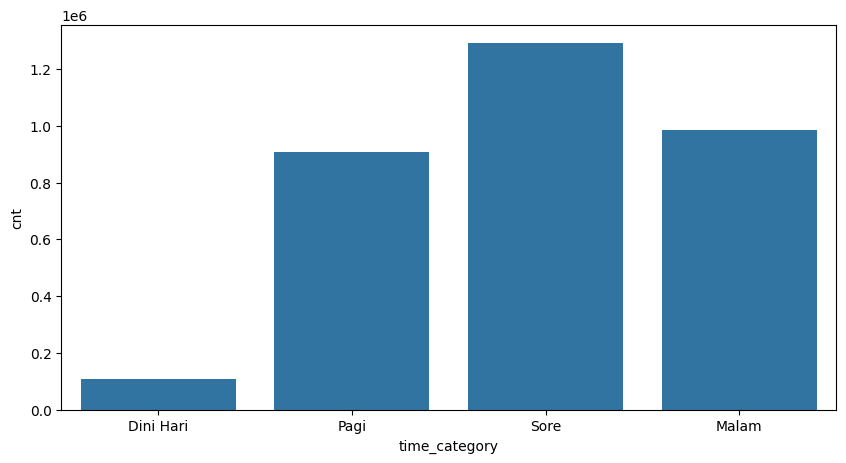

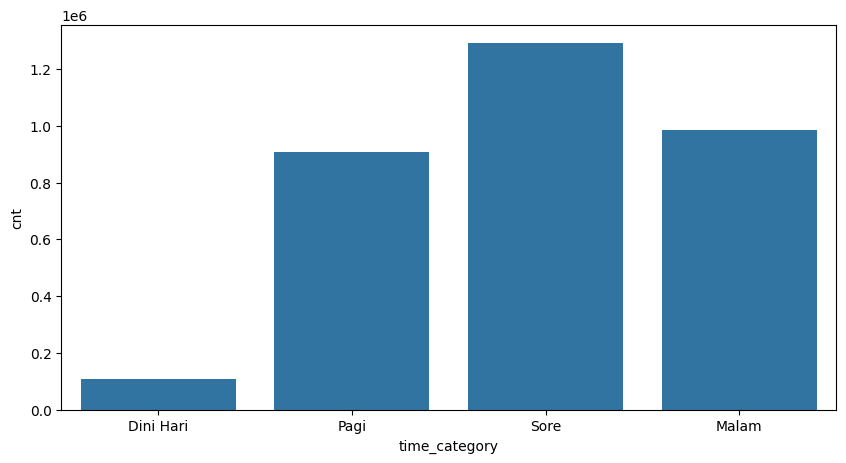

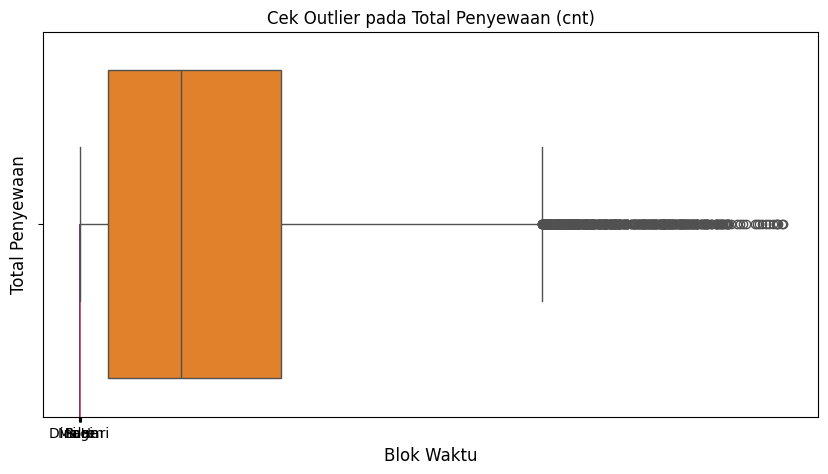

In [20]:
print(df_hour.info())
print(df_hour.isna().sum())
print("Jumlah duplikasi pada dataset: ", df_hour.duplicated().sum())
print(df_hour.describe())

sns.boxplot(x=df_hour['cnt'])
plt.title('Cek Outlier pada Total Penyewaan (cnt)')
plt.show()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
None
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday 

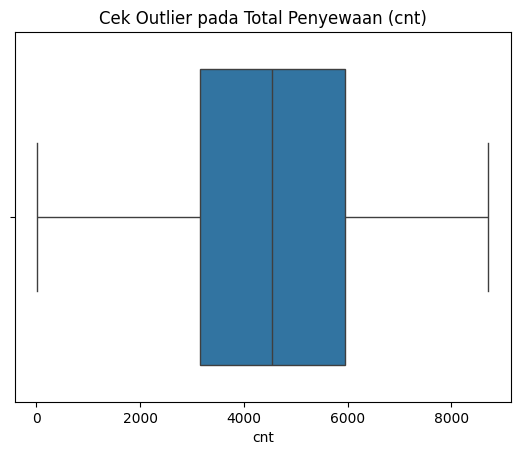

In [21]:
print(df_day.info())
print(df_day.isna().sum())
print("Jumlah duplikasi pada dataset: ", df_day.duplicated().sum())
print(df_day.describe())

sns.boxplot(x=df_day['cnt'])
plt.title('Cek Outlier pada Total Penyewaan (cnt)')
plt.show()

**Insight:**
- Dataset hour.csv berhasil dimuat dengan total 17.379 baris dan 17 kolom. Sementara day.csv berhasil dimuat dengan total 731 baris dan 16 kolom.
- Tidak ditemukan missing value (NaN/Null) pada seluruh dataset
- Terdapat ketidaksesuaian tipe data dteday yang terbaca object (seharusnya datetime)
- Data per jam (hour): memiliki 17379 baris data. rata-rata penyewaan perjam adalah 189 sepeda, dengan rekor tertinggi 977 sepeda
- Data per hari (day): memiliki 731 barisa data. rata-rata penyewaan perhari adalah 4504 sepeda, dengan rekor tertinggi 8714 sepeda
- Data Per Jam (Gambar 1): Terdapat banyak sekali outlier pada kolom cnt. Hal ini wajar (dan bukan kesalahan data) karena pola penyewaan per jam sangat bergantung pada jam sibuk (rush hour), akhir pekan, atau hari libur nasional
- Data Harian (Gambar 2): Tidak ditemukan outlier yang signifikan pada kolom cnt di level harian. Hal ini menunjukkan bahwa secara keseluruhan, performa penyewaan harian cenderung stabil dan tersebar secara normal di sekitar nilai rata-rata
- Suhu (temp/atemp): Rata-rata suhu berada di angka 0,49 (skala ternormalisasi). Hal ini menunjukkan rata-rata kondisi cuaca berada di suhu sedang (hangat)
- Kelembapan (hum): Rata-rata kelembapan udara adalah 62,7% (0,62)
- Workingday: Sekitar 68% data tercatat sebagai hari kerja, yang mengindikasikan bahwa data didominasi oleh aktivitas rutin harian
- Outlier pada data per jam (hour.csv) diputuskan untuk tetap dipertahankan karena merupakan representasi kondisi riil lonjakan permintaan pada jam-jam tertentu (Natural Variability)

### Cleaning Data

In [22]:
df_hour['dteday'] = pd.to_datetime(df_hour['dteday'])
df_day['dteday'] = pd.to_datetime(df_day['dteday'])

# mapping season
season_mapping = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
df_hour['season'] = df_hour['season'].map(season_mapping)
df_day['season'] = df_day['season'].map(season_mapping)

# mapping weather
weather_mapping = {1: 'Clear', 2: 'Mist', 3: 'Light Snow/Rain', 4: 'Heavy Rain/Snow'}
df_hour['weathersit'] = df_hour['weathersit'].map(weather_mapping)
df_day['weathersit'] = df_day['weathersit'].map(weather_mapping)

# mapping month
month_mapping = {1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June', 7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'}
df_hour['mnth'] = df_hour['mnth'].map(month_mapping)
df_day['mnth'] = df_day['mnth'].map(month_mapping)

# mapping weekday
weekday_mapping = {0: 'Sunday', 1: 'Monday', 2: 'Tuesday', 3: 'Wednesday', 4: 'Thursday', 5: 'Friday', 6: 'Saturday'}
df_hour['weekday'] = df_hour['weekday'].map(weekday_mapping)
df_day['weekday'] = df_day['weekday'].map(weekday_mapping)

print(df_hour.head())
print(df_day.info())

   instant     dteday  season  yr     mnth  hr  holiday   weekday  workingday  \
0        1 2011-01-01  Spring   0  January   0        0  Saturday           0   
1        2 2011-01-01  Spring   0  January   1        0  Saturday           0   
2        3 2011-01-01  Spring   0  January   2        0  Saturday           0   
3        4 2011-01-01  Spring   0  January   3        0  Saturday           0   
4        5 2011-01-01  Spring   0  January   4        0  Saturday           0   

  weathersit  temp   atemp   hum  windspeed  casual  registered  cnt  
0      Clear  0.24  0.2879  0.81        0.0       3          13   16  
1      Clear  0.22  0.2727  0.80        0.0       8          32   40  
2      Clear  0.22  0.2727  0.80        0.0       5          27   32  
3      Clear  0.24  0.2879  0.75        0.0       3          10   13  
4      Clear  0.24  0.2879  0.75        0.0       0           1    1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (t

**Insight:**
- Kolom dteday telah berhasil diubah dari tipe data object menjadi datetime64[ns]
- Kolom kategori seperti season, mnth, weekday, dan weathersit telah diubah dari angka numerik (seperti 1, 2, 3) menjadi label kategori (string)
- Dataset sekarang memiliki campuran tipe data yang ideal: 7 kolom integer, 4 kolom float (suhu, kelembapan, dsb), 4 kolom object (label), dan 1 kolom datetime

## Exploratory Data Analysis (EDA)

### Explore Data df_hour (pola jam-jaman)

In [23]:
print(df_hour.groupby(by='hr').agg({'cnt': ['max', 'min', 'mean', 'sum']}))

    cnt                        
    max min        mean     sum
hr                             
0   283   2   53.898072   39130
1   168   1   33.375691   24164
2   132   1   22.869930   16352
3    79   1   11.727403    8174
4    28   1    6.352941    4428
5    66   1   19.889819   14261
6   213   1   76.044138   55132
7   596   1  212.064649  154171
8   839   5  359.011004  261001
9   426  14  219.309491  159438
10  539   8  173.668501  126257
11  663  10  208.143054  151320
12  776   3  253.315934  184414
13  760  11  253.661180  184919
14  750  12  240.949246  175652
15  750   7  251.233196  183149
16  783  11  311.983562  227748
17  976  15  461.452055  336860
18  977  23  425.510989  309772
19  743  11  311.523352  226789
20  567  11  226.030220  164550
21  584   6  172.314560  125445
22  502   9  131.335165   95612
23  256   2   87.831044   63941


**Insight:**
- Rata-rata paling tinggi ada di jam 5 dan 6 sore (di atas 300 pada jam 4 - 7), serta jam 8 pagi
- Indikasi kuat bahwa sepeda digunakan untuk keperluan berangkat/pulang kerja

### Explore Data df_day (pola hari & musim)

In [24]:
# penyewaan berdasarkan hari kerja vs hari libur
print(df_day.groupby(by='workingday').agg({'cnt': ['max', 'min', 'mean']}))

# penyewaan berdasarkan musim
print(df_day.groupby(by='season').agg({'cnt': ['max', 'min', 'mean', 'sum']})
      .sort_values(by=('cnt', 'mean'), ascending=False))

             cnt                  
             max  min         mean
workingday                        
0           8714  605  4330.168831
1           8362   22  4584.820000
         cnt                            
         max   min         mean      sum
season                                  
Fall    8714  1115  5644.303191  1061129
Summer  8362   795  4992.331522   918589
Winter  8555    22  4728.162921   841613
Spring  7836   431  2604.132597   471348


**Insight:**
- Rata-rata hari kerja (4584) lebih tinggi daripada hari libur (4330)
- Nilai minimum pada hari kerja hanya 22 sepeda (kemungkinan badai atau bersalju), sementara saat hari libur pun mencapai 605 sepeda
- Hari kerja menyumbang volume penyewaan lebih besar, tetapi hari linur memiliki base penyewaan lebih stabil

### Explore berdasarkan cuaca (weathersit)

In [25]:
print(df_day.groupby(by='weathersit').cnt.mean().sort_values(ascending=False))

weathersit
Clear              4876.786177
Mist               4035.862348
Light Snow/Rain    1803.285714
Name: cnt, dtype: float64


**Insight:**
- Kondisi cuaca berpengaruh signifikan terhadap minat pengguna. Penyewaan tertinggi terjadi saat cuaca Clear/Partly Cloudy, sementara saat terjadi Light Snow/Rain, jumlah penyewaan menurun drastis lebih dari 60% dibandingkan saat cuaca cerah. Ini menunjukkan faktor keamanan dan kenyamanan menjadi prioritas utama pengguna sepeda.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

C:\Users\asus\AppData\Local\Temp\ipykernel_28220\1020330824.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='hr', y='cnt', data=df_hour, hue='workingday', marker='o', ci=None)


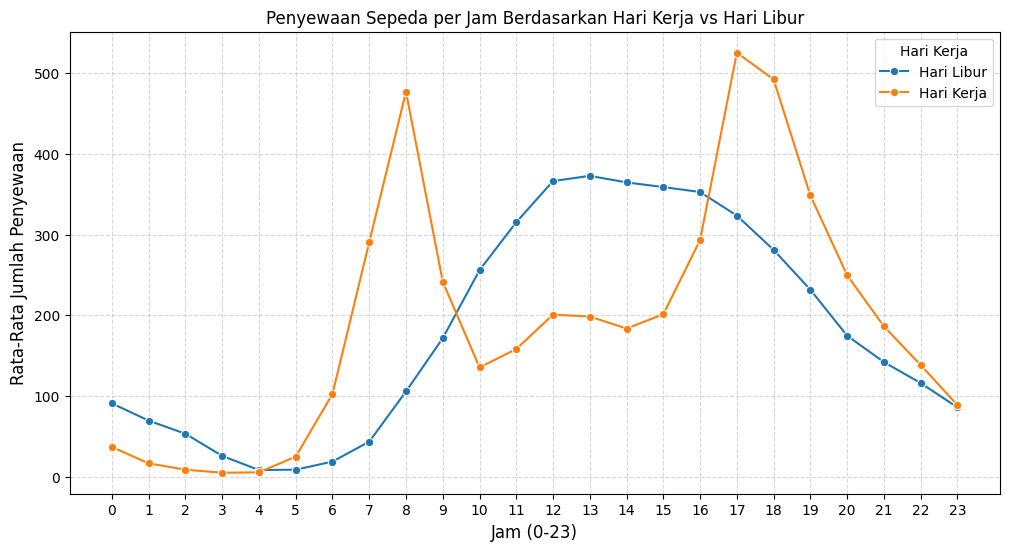

In [26]:
plt.figure(figsize=(12, 6))

sns.lineplot(x='hr', y='cnt', data=df_hour, hue='workingday', marker='o', ci=None)

plt.title('Penyewaan Sepeda per Jam Berdasarkan Hari Kerja vs Hari Libur')
plt.xlabel('Jam (0-23)', fontsize=12)
plt.ylabel('Rata-Rata Jumlah Penyewaan', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Hari Kerja', labels=['Hari Libur', 'Hari Kerja'])
plt.show()

**Insight:**
- Terlihat perbedaan pola yang sangat kontras. Pada hari kerja, terdapat dua puncak utama (bimodal) yaitu jam 08:00 dan 17:00-18:00, yang menandakan penggunaan sepeda untuk komuting (berangkat/pulang kerja). Sebaliknya, pada hari libur, penyewaan melonjak secara bertahap mulai siang hari dan mencapai puncaknya di jam 12:00-15:00, yang mengindikasikan penggunaan sepeda untuk tujuan rekreasi.

### Pertanyaan 2:

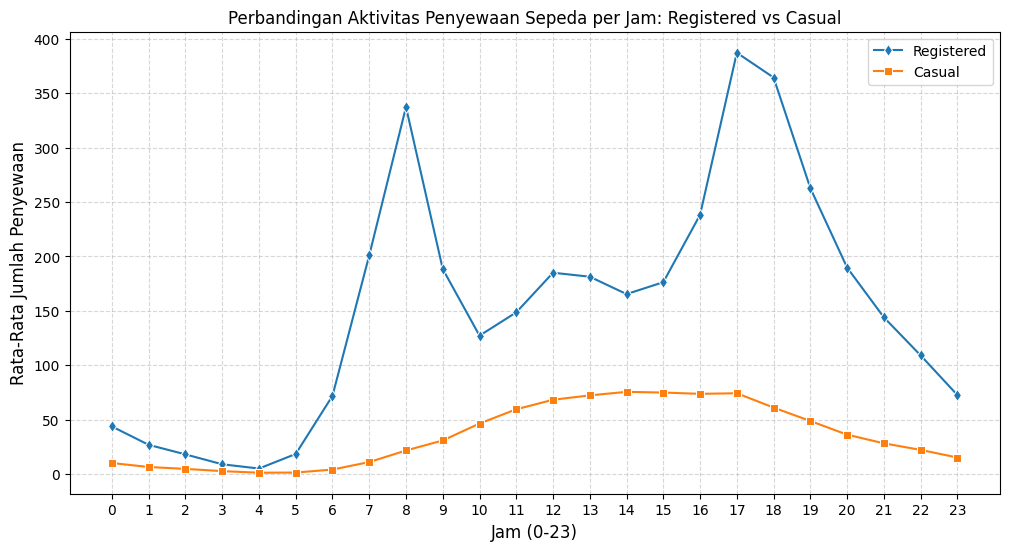

In [27]:
hourly_user_type = df_hour.groupby('hr'). agg({'casual': 'mean', 'registered': 'mean'}).reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='hr', y='registered', data=hourly_user_type, marker='d', label='Registered')
sns.lineplot(x='hr', y='casual', data=hourly_user_type, marker='s', label='Casual')

plt.title('Perbandingan Aktivitas Penyewaan Sepeda per Jam: Registered vs Casual')
plt.xlabel('Jam (0-23)', fontsize=12)
plt.ylabel('Rata-Rata Jumlah Penyewaan', fontsize=12)
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Insight:**
- Pengguna Registered mendominasi volume penyewaan secara keseluruhan dengan pola puncak di jam sibuk pagi dan sore. Namun, pengguna Casual menunjukkan peningkatan aktivitas yang paling signifikan pada rentang jam 11:00 hingga 16:00. Meskipun jumlahnya tidak sebanyak pengguna Registered, tren pengguna Casual cenderung lebih stabil di siang hari tanpa ada lonjakan tajam di pagi hari, menunjukkan mereka lebih aktif di jam-jam santai/wisata

## Analisis Lanjutan (Opsional)

C:\Users\asus\AppData\Local\Temp\ipykernel_28220\644687336.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=time_group_analysis.index, y='cnt', data=time_group_analysis, palette='magma')


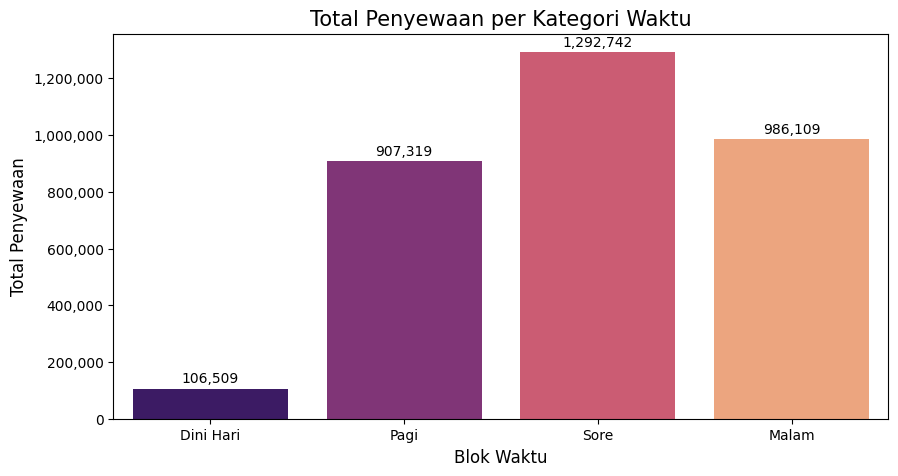

In [37]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=time_group_analysis.index, y='cnt', data=time_group_analysis, palette='magma')

plt.title('Total Penyewaan per Kategori Waktu', fontsize=15)
plt.xlabel('Blok Waktu', fontsize=12)
plt.ylabel('Total Penyewaan', fontsize=12)

# Format angka
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Label di atas bar
for i, v in enumerate(time_group_analysis['cnt']):
    ax.text(i, v + 20000, f"{v:,.0f}", ha='center')

plt.show()

**Insight:**
- Penyewaan tertinggi terjadi pada waktu sore hari
Total penyewaan paling besar ada di kategori sore (12.00–18.00). Ini menunjukkan jika aktivitas pengguna meningkat setelah jam kerja/sekolah, kemungkinan untuk pulang atau aktivitas santai.
- Waktu malam juga memiliki tingkat penyewaan yang tinggi
Kategori malam (18.00–24.00) ada di posisi kedua. Ini bisa jadi karena orang masih beraktivitas di luar rumah, seperti aktivitas malam atau perjalanan pulang.
- Pagi hari menunjukkan penggunaan yang cukup tinggi
Penyewaan di pagi (06.00–12.00) juga signifikan, kemungkinan besar terkait dengan aktivitas berangkat kerja atau sekolah.
- Dini hari memiliki penyewaan paling rendah
Pada dini hari (00.00–06.00), jumlah penyewaan sangat kecil. Ini wajar karena sebagian besar orang tidak beraktivitas pada jam tersebut.

## Conclusion

- Terdapat perbedaan pola aktivitas yang sangat signifikan antara hari kerja dan hari libur. Pada hari kerja, pola penyewaan bersifat bimodal dengan dua puncak utama pada jam 08:00 dan 17:00-18:00, yang menunjukkan bahwa sepeda digunakan sebagai moda transportasi utama untuk bekerja atau sekolah (commuting). Sementara itu, pada hari libur, aktivitas penyewaan cenderung landai di pagi hari dan baru meningkat secara bertahap mulai pukul 10:00 hingga puncaknya di siang hari (jam 12:00-15:00). Hal ini mengindikasikan bahwa pada hari libur, penggunaan sepeda lebih bersifat rekreasi atau santai
- Pengguna Registered mendominasi total volume penyewaan di sepanjang waktu dengan pola yang mengikuti jam sibuk (rush hour). Namun, pengguna Casual menunjukkan karakteristik yang berbeda, di mana mereka paling aktif melakukan penyewaan pada rentang jam 11:00 hingga 16:00 (siang hari). Tidak seperti pengguna Registered yang memiliki lonjakan tajam di pagi hari, pengguna Casual lebih banyak menyewa sepeda di jam-jam santai. Informasi ini sangat berguna untuk strategi pemasaran, misalnya memberikan promo khusus pengguna Casual di siang hari saat kapasitas sepeda sedang tidak terlalu terbebani oleh pengguna rutin (Registered)